In [8]:
import numpy as np                           # arrays and linear algebra
import pandas as pd                          # tables
import matplotlib.pyplot as plt 

from sklearn import decomposition            # PCA
from sklearn.preprocessing import StandardScaler, scale   # scaling [WEATHER][PCA]
from sklearn.decomposition import PCA        # same class as decomposition.PCA

np.set_printoptions(suppress=True)


In [9]:
cohort = pd.read_csv("../../data/clean/pulse_ox_cleaned.csv")
cohort_numeric = cohort.iloc[:, 3:]
cohort_numeric.head()

,durationInMs,deepSleepDurationInMs,lightSleepDurationInMs,remSleepInMs,awakeDurationInMs,overallSleepScore,breathsPerMinute_mean,breathsPerMinute_std,breathsPerMinute_min,breathsPerMinute_max,...,restingHeartRateInBeatsPerMinute,minHeartRateInBeatsPerMinute,maxHeartRateInBeatsPerMinute,averageStressInStressLevel,maxStressInStressLevel,steps,activeKilocalories,bmrKilocalories,moderateIntensityDurationInMs,vigorousIntensityDurationInMs
0,29340000,3540000.0,19800000.0,6000000.0,60000.0,78.0,17.341388,2.072629,8.00,23.00,...,51.0,48.0,107.0,43.0,99.0,2825,126,2333,0,0
1,23340000,3660000.0,17100000.0,2580000.0,300000.0,73.0,17.201802,1.916917,10.83,22.58,...,50.0,46.0,120.0,41.0,99.0,8040,628,2339,1440000,120000
2,20940000,4200000.0,13140000.0,3600000.0,60000.0,76.0,15.170688,1.796894,7.50,19.41,...,48.0,45.0,103.0,40.0,98.0,3394,160,2333,0,0
3,21240000,3660000.0,14880000.0,2700000.0,1680000.0,60.0,18.227795,1.968694,11.66,23.41,...,53.0,45.0,109.0,53.0,98.0,5823,275,2333,0,0
4,24000000,2700000.0,17160000.0,2580000.0,180000.0,75.0,15.627893,2.401607,7.58,21.08,...,50.0,48.0,106.0,37.0,95.0,5947,250,2333,0,0


In [10]:
cohort_scaled = StandardScaler().fit_transform(cohort_numeric)
cohort_scaled = pd.DataFrame(cohort_scaled, columns=cohort_numeric.columns)
cohort_scaled.head()

,durationInMs,deepSleepDurationInMs,lightSleepDurationInMs,remSleepInMs,awakeDurationInMs,overallSleepScore,breathsPerMinute_mean,breathsPerMinute_std,breathsPerMinute_min,breathsPerMinute_max,...,restingHeartRateInBeatsPerMinute,minHeartRateInBeatsPerMinute,maxHeartRateInBeatsPerMinute,averageStressInStressLevel,maxStressInStressLevel,steps,activeKilocalories,bmrKilocalories,moderateIntensityDurationInMs,vigorousIntensityDurationInMs
0,0.633670,-0.442191,0.576904,0.729546,-0.794905,0.720557,0.250026,-0.552908,-0.900375,-0.252812,...,-0.969722,-0.875145,-0.539657,0.536424,0.819268,-0.928189,-0.735710,0.661508,-0.44264,-0.380068
1,-0.452481,-0.375326,-0.013481,-0.722219,-0.656482,0.403073,0.178425,-0.880722,0.494936,-0.449863,...,-1.081412,-1.124709,0.293443,0.333979,0.819268,0.524351,0.074139,0.682619,0.08886,-0.234909
2,-0.886941,-0.074436,-0.879379,-0.289236,-0.794905,0.593563,-0.863454,-1.133401,-1.146896,-1.937124,...,-1.304794,-1.249491,-0.795996,0.232757,0.671059,-0.769704,-0.680860,0.661508,-0.44264,-0.380068
3,-0.832634,-0.375326,-0.498908,-0.671280,0.139450,-0.422386,0.704717,-0.771719,0.904161,-0.060454,...,-0.746340,-1.249491,-0.411488,1.548647,0.671059,-0.093152,-0.495337,0.661508,-0.44264,-0.380068
4,-0.333005,-0.910242,-0.000361,-0.722219,-0.725694,0.530067,-0.628926,0.139673,-1.107453,-1.153614,...,-1.081412,-0.875145,-0.603742,-0.070910,0.226431,-0.058614,-0.535668,0.661508,-0.44264,-0.380068


In [11]:
pca = decomposition.PCA()
pca.fit(cohort_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [12]:
# Share of the total variance carried by each PC
explained_variance = pca.explained_variance_ratio_
print("explained variance ratio:", np.round(explained_variance, 4))

# Running total, and the first k that reaches a target
cumulative = np.cumsum(explained_variance)
print("cumulative              :", np.round(cumulative, 4))
k_95 = int(np.searchsorted(cumulative, 0.95)) + 1      # +1 because counting starts at 0  [SVD]
print("components needed for 95%:", k_95)

explained variance ratio: [0.2317 0.1153 0.1056 0.0839 0.0659 0.0506 0.0441 0.0394 0.0351 0.0342
 0.0294 0.0259 0.0193 0.019  0.0158 0.0139 0.0126 0.0098 0.0094 0.0086
 0.0075 0.0059 0.0052 0.0047 0.0039 0.0034 0.0001]
cumulative              : [0.2317 0.347  0.4525 0.5364 0.6023 0.653  0.6971 0.7366 0.7716 0.8058
 0.8352 0.8611 0.8804 0.8994 0.9151 0.929  0.9417 0.9515 0.9608 0.9694
 0.9769 0.9828 0.988  0.9926 0.9965 0.9999 1.    ]
components needed for 95%: 18


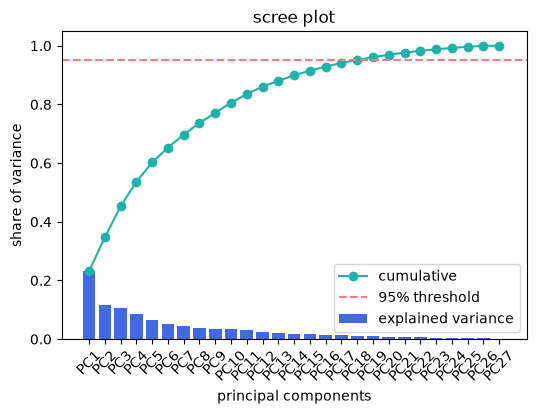

In [13]:
# Scree plot: bars = each PC's share, line = running total
pcs = ["PC1", "PC2", "PC3", "PC4","PC5", "PC6", "PC7", "PC8", "PC9", "PC10", "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19","PC20","PC21","PC22", "PC23","PC24","PC25","PC26","PC27"]
plt.figure(figsize=(6, 4))
plt.bar(pcs, explained_variance, color="RoyalBlue", label="explained variance")
plt.plot(pcs, cumulative, marker="o", color="LightSeaGreen", label="cumulative")
plt.xlabel("principal components")
plt.xticks(rotation=45)
plt.ylabel("share of variance")
plt.title("scree plot")
plt.axhline(y=0.95, color="LightCoral", linestyle="--", label="95% threshold")
plt.legend()
plt.savefig("../../images/pca/pulse_ox_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
loadings = pca.components_.T
df_loadings = pd.DataFrame(loadings, columns=["PC1", "PC2", "PC3","PC4","PC5","PC6","PC7","PC8","PC9","PC10", "PC11","PC12","PC13","PC14","PC15","PC16","PC17","PC18","PC19","PC20","PC21","PC22", "PC23","PC24","PC25","PC26","PC27"], index=cohort_scaled.columns)
print(df_loadings.round(2), "\n")

                                   PC1   PC2   PC3   PC4   PC5   PC6   PC7  \
durationInMs                     -0.15 -0.23  0.41 -0.22  0.06 -0.05 -0.01   
deepSleepDurationInMs            -0.08  0.03 -0.04 -0.20 -0.28  0.25  0.29   
lightSleepDurationInMs           -0.04 -0.19  0.41 -0.06  0.24 -0.16 -0.21   
remSleepInMs                     -0.20 -0.19  0.18 -0.25 -0.12  0.01  0.17   
awakeDurationInMs                 0.04 -0.09  0.06  0.22  0.38 -0.18 -0.10   
overallSleepScore                -0.29 -0.06  0.12 -0.26 -0.24  0.07  0.11   
breathsPerMinute_mean             0.25 -0.26 -0.06 -0.14  0.04  0.18 -0.08   
breathsPerMinute_std              0.04 -0.03  0.17  0.32  0.16 -0.02  0.65   
breathsPerMinute_min              0.20 -0.19 -0.17 -0.25 -0.14  0.10 -0.34   
breathsPerMinute_max              0.24 -0.26  0.04 -0.01  0.13  0.16  0.29   
spo2_mean                        -0.02  0.30  0.06 -0.28  0.38  0.28 -0.02   
spo2_std                          0.01 -0.22  0.13  0.42 -0.20  

In [16]:
pc1_sorted = df_loadings.iloc[:,0].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC1 loadings sorted by magnitude:\n\n",pc1_sorted)

PC1 loadings sorted by magnitude:

 restingHeartRateInBeatsPerMinute    0.344770
minHeartRateInBeatsPerMinute        0.306581
lastNightAvg                       -0.296852
overallSleepScore                  -0.287497
lastNight5MinHigh                  -0.286502
activeKilocalories                  0.285339
averageStressInStressLevel          0.267426
breathsPerMinute_mean               0.246484
breathsPerMinute_max                0.240063
maxHeartRateInBeatsPerMinute        0.209604
remSleepInMs                       -0.198644
breathsPerMinute_min                0.198434
moderateIntensityDurationInMs       0.193522
vigorousIntensityDurationInMs       0.172073
durationInMs                       -0.145545
spo2_count                         -0.134372
maxStressInStressLevel              0.103869
bmrKilocalories                     0.097000
deepSleepDurationInMs              -0.075474
lightSleepDurationInMs             -0.043530
breathsPerMinute_std                0.041672
awakeDurationInMs  

In [17]:
pc2_sorted = df_loadings.iloc[:,1].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC2 loadings sorted by magnitude:\n\n",pc2_sorted)

PC2 loadings sorted by magnitude:

 spo2_min                            0.304819
spo2_mean                           0.301722
breathsPerMinute_mean              -0.264955
breathsPerMinute_max               -0.255140
durationInMs                       -0.230153
spo2_count                         -0.224484
activeKilocalories                  0.222341
maxHeartRateInBeatsPerMinute        0.222255
spo2_std                           -0.220127
maxStressInStressLevel              0.219579
steps                               0.217616
vigorousIntensityDurationInMs       0.202327
bmrKilocalories                     0.197916
remSleepInMs                       -0.192054
breathsPerMinute_min               -0.188333
lightSleepDurationInMs             -0.185725
minHeartRateInBeatsPerMinute       -0.177699
lastNightAvg                        0.167753
lastNight5MinHigh                   0.149906
moderateIntensityDurationInMs       0.143592
restingHeartRateInBeatsPerMinute   -0.122863
averageStressInStre

In [18]:
pc3_sorted = df_loadings.iloc[:,2].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC3 loadings sorted by magnitude:\n\n",pc3_sorted)

PC3 loadings sorted by magnitude:

 lightSleepDurationInMs              0.413312
durationInMs                        0.411611
spo2_count                          0.361176
vigorousIntensityDurationInMs       0.270286
maxHeartRateInBeatsPerMinute        0.265081
moderateIntensityDurationInMs       0.249447
maxStressInStressLevel              0.215702
spo2_max                            0.208116
activeKilocalories                  0.193135
remSleepInMs                        0.183866
breathsPerMinute_std                0.170496
breathsPerMinute_min               -0.169321
steps                               0.144383
averageStressInStressLevel          0.129935
spo2_std                            0.126934
overallSleepScore                   0.120771
spo2_min                           -0.105070
lastNight5MinHigh                   0.079921
spo2_mean                           0.063435
breathsPerMinute_mean              -0.063018
awakeDurationInMs                   0.061139
bmrKilocalories    

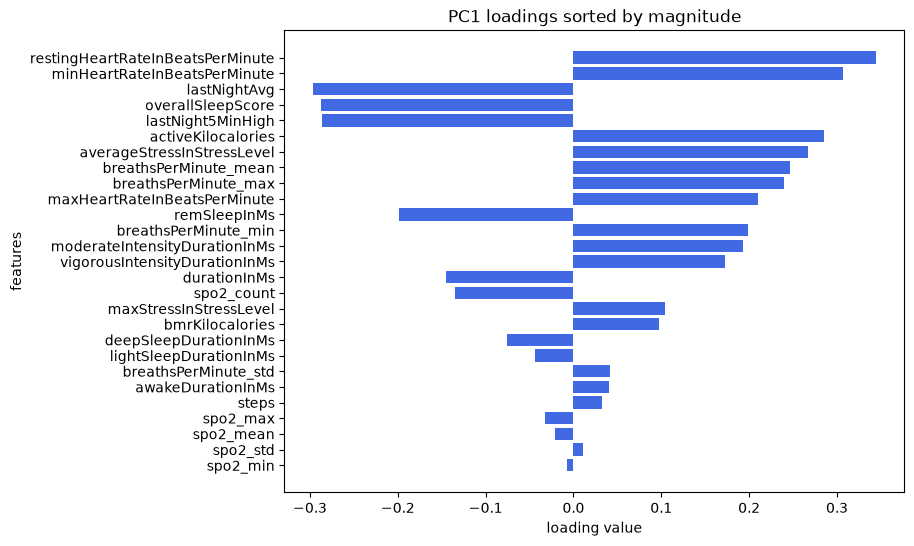

In [20]:
plt.figure(figsize=(8, 6))
plt.barh(pc1_sorted.index,pc1_sorted.values, color="RoyalBlue", label="PC1 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC1 loadings sorted by magnitude")
plt.savefig("../../images/pca/pulse_ox_pc1_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

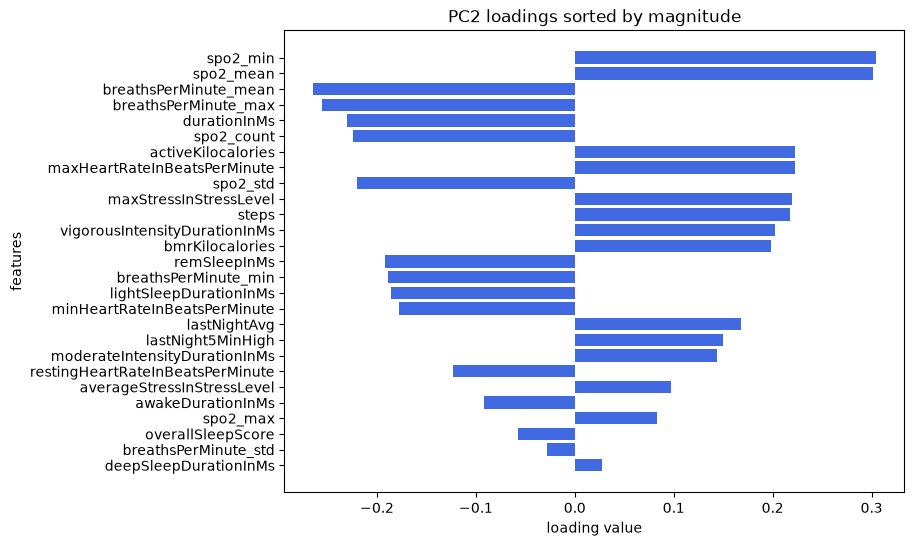

In [21]:
plt.figure(figsize=(8,6))
plt.barh(pc2_sorted.index,pc2_sorted.values, color="RoyalBlue", label="PC2 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC2 loadings sorted by magnitude")
plt.savefig("../../images/pca/pulse_ox_pc2_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

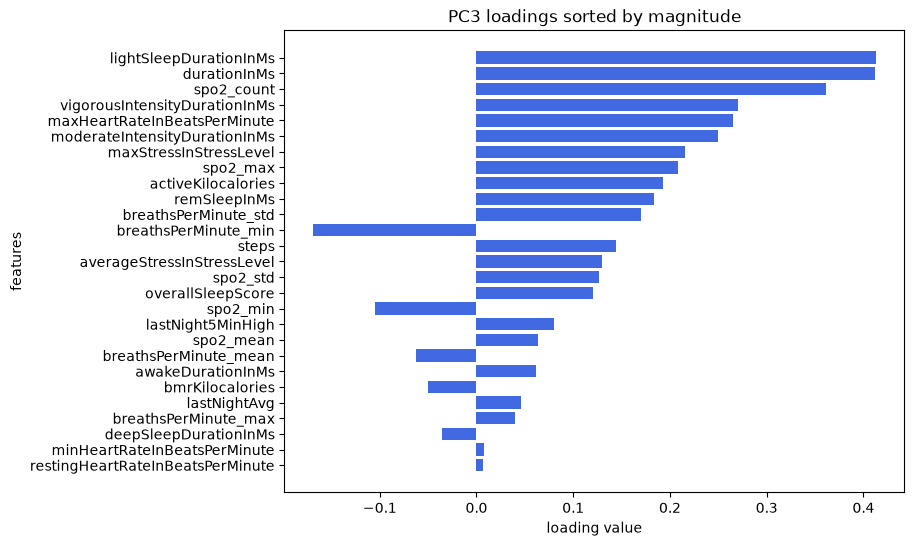

In [22]:
plt.figure(figsize=(8,6))
plt.barh(pc3_sorted.index,pc3_sorted.values, color="RoyalBlue", label="PC3 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC3 loadings sorted by magnitude")
plt.savefig("../../images/pca/pulse_ox_pc3_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
Xd = cohort_scaled                            # (18731, 18), standardized to match the sklearn PCA
n = Xd.shape[0]                               # number of samples (nights)

Uf, Sf, Vtf = np.linalg.svd(Xd, full_matrices=False)       # 1. economy SVD (scaled data is already centered)
print("U:", Uf.shape, "  S:", Sf.shape, "  Vt:", Vtf.shape)

var_pc = Sf**2 / (n - 1)                      # 2. variance along each PC = eigenvalues

C = (Xd.T @ Xd) / (n - 1)                     # 3. the covariance matrix, 18 x 18
eig = np.sort(np.linalg.eigvalsh(C))[::-1]    # its eigenvalues, sorted biggest first

print("\n\nvariance from the SVD       :", np.round(var_pc, 4))
print("\n\neigenvalues of the covariance:", np.round(eig, 4))
print("\n\nidentical:", np.allclose(var_pc, eig))

pct = 100 * var_pc / var_pc.sum()             # 4. percent of variance (matches explained_variance_ratio_)
print("\n\npercent of variance:", np.round(pct, 2))

U: (8729, 27)   S: (27,)   Vt: (27, 27)


variance from the SVD       : [6.2558 3.1131 2.8507 2.2661 1.7795 1.3676 1.1919 1.0646 0.9466 0.9232
 0.7941 0.6995 0.5214 0.5118 0.4257 0.3747 0.3413 0.2653 0.2527 0.232
 0.2025 0.1581 0.1397 0.1257 0.1043 0.0916 0.0037]


eigenvalues of the covariance: [6.2558 3.1131 2.8507 2.2661 1.7795 1.3676 1.1919 1.0646 0.9466 0.9232
 0.7941 0.6995 0.5214 0.5118 0.4257 0.3747 0.3413 0.2653 0.2527 0.232
 0.2025 0.1581 0.1397 0.1257 0.1043 0.0916 0.0037]


identical: True


percent of variance: [23.17 11.53 10.56  8.39  6.59  5.06  4.41  3.94  3.51  3.42  2.94  2.59
  1.93  1.9   1.58  1.39  1.26  0.98  0.94  0.86  0.75  0.59  0.52  0.47
  0.39  0.34  0.01]
